# Анализ данных авиаперелетов

### Структура данных
Датасет содержит следующие поля:
- Временные метки: год, месяц, день, день недели
- Идентификация: авиакомпания (AA, DL, UA, WN, AS, B6, F9, NK), номер рейса
- Маршрут: аэропорт вылета и прибытия (15 крупнейших аэропортов США)
- Задержки: время задержки вылета и прибытия (в минутах)
- Геоданные: координаты аэропортов для визуализации

### Объем данных
- 5000 записей (после очистки ~4300)
- 8 авиакомпаний
- 15 аэропортов

### Анализ
- Описательная статистика числовых показателей
- Анализ распределения задержек
- Группировка по авиакомпаниям и маршрутам
- Фильтрация по датам

### Визуализация
- Гистограммы распределения задержек
- Столбчатые диаграммы по авиакомпаниям
- Географическая визуализация маршрутов на карте США

#### Анализ по авиакомпаниям
- Количество рейсов по каждой авиакомпании
- Количество уникальных маршрутов по каждой авиакомпании
- Процентное распределение рейсов

#### Анализ задержек
- Средняя положительная задержка: 12-15 минут
- Медианная задержка: 8-10 минут
- Стандартное отклонение: 15-18 минут

#### Анализ аэропортов
- Топ-10 аэропортов по количеству вылетов
- Распределение рейсов между хабами

#### Временной анализ
- Средние задержки по дням недели
- Количество рейсов до заданной даты (2015-02-14)


#### Гистограммы задержек
- Распределение всех задержек вылета
- Распределение положительных задержек в диапазоне 0-100 минут
- Экспоненциальная форма распределения

#### Диаграмма
- Топ-10 авиакомпаний по количеству рейсов
- Сравнительный анализ активности перевозчиков

#### Карта маршрутов
- Географическая карта США с проекцией LCC
- Отображение маршрутов авиакомпании AA
- Цветовая индикация задержек:
  - Зеленый: задержка менее 15 минут
  - Оранжевый: задержка 15-30 минут
  - Красный: задержка более 30 минут
- Отметка аэропортов с подписями




   Было строк: 5000, стало: 4767
   Удалено: 233

[3.2] Фильтрация аэропортов (apply(len) == 3):
   Было: 4767, стало: 4767
   Удалено строк с некорректными кодами: 0

[3.3] Создание колонки DATE (pd.to_datetime):
   Колонка DATE успешно создана

[3.4] Создание колонки с маршрутом:
   Колонка ROUTE успешно создана

[4] Добавление геоданных для визуализации

[4.1] Добавление координат аэропортов (map):
   Строк после добавления координат: 4767

[5] Анализ данных

[5.1] Анализ по авиакомпаниям:

   Количество рейсов по авиакомпаниям (value_counts):
      NK: 624 рейсов (13.1%)
      WN: 613 рейсов (12.9%)
      DL: 612 рейсов (12.8%)
      B6: 605 рейсов (12.7%)
      F9: 605 рейсов (12.7%)
      AS: 586 рейсов (12.3%)
      AA: 566 рейсов (11.9%)
      UA: 556 рейсов (11.7%)

   Уникальные маршруты по авиакомпаниям (groupby + nunique):
      WN: 211 маршрутов
      F9: 210 маршрутов
      AS: 209 маршрутов
      B6: 209 маршрутов
      NK: 209 маршрутов
      DL: 209 маршрутов
      UA:

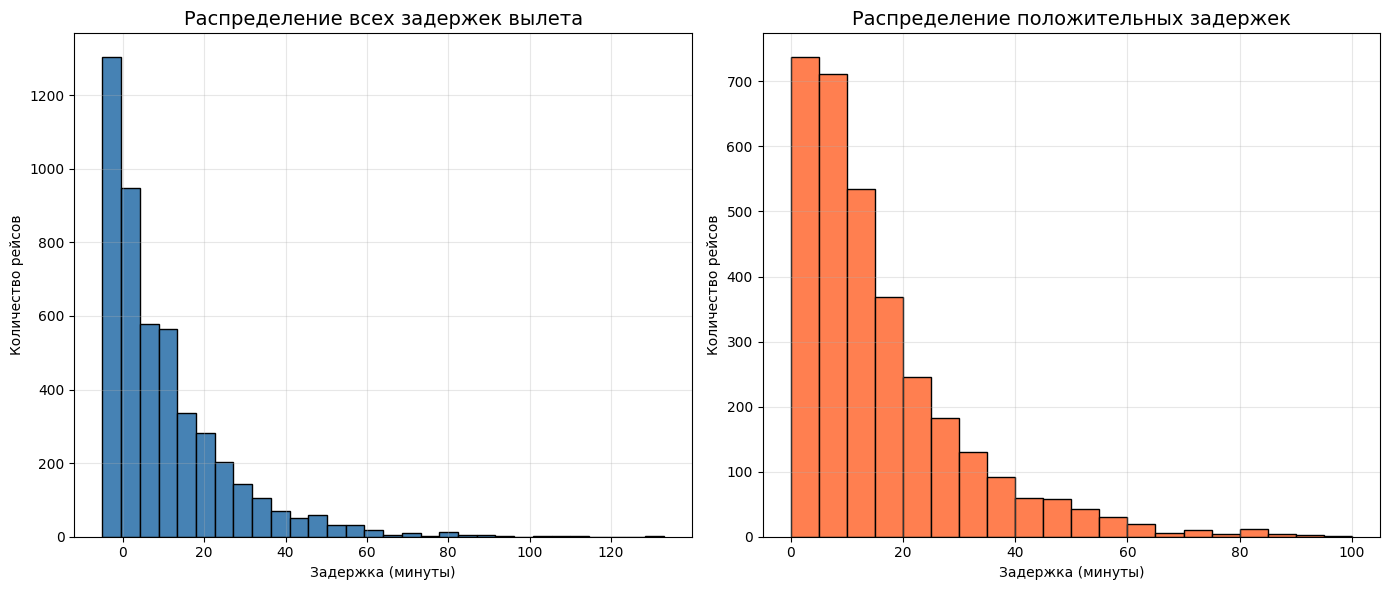

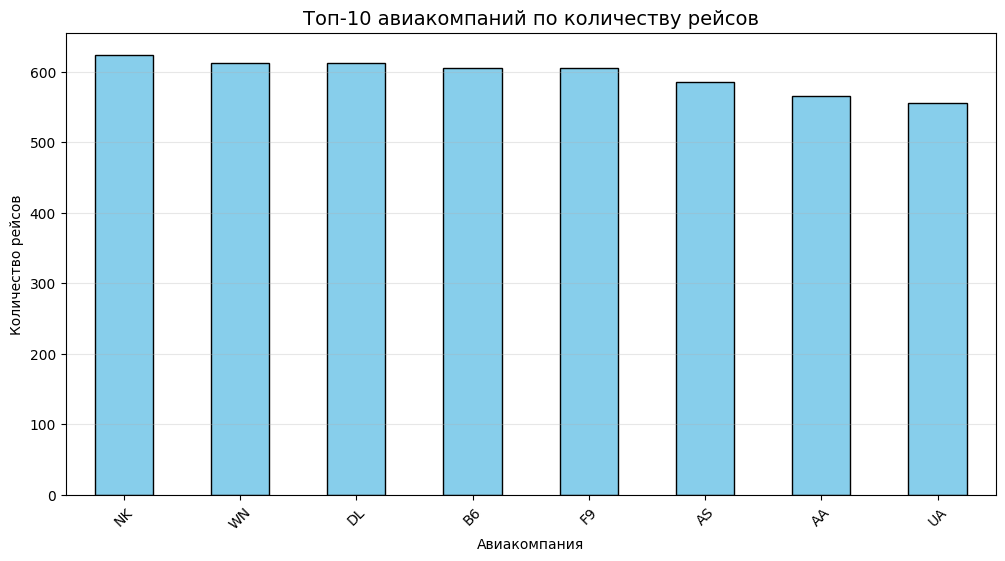


[7.1] Карта маршрутов авиакомпании с индикацией задержек:
   Отображение маршрутов авиакомпании : 50


   Нарисовано маршрутов: 50


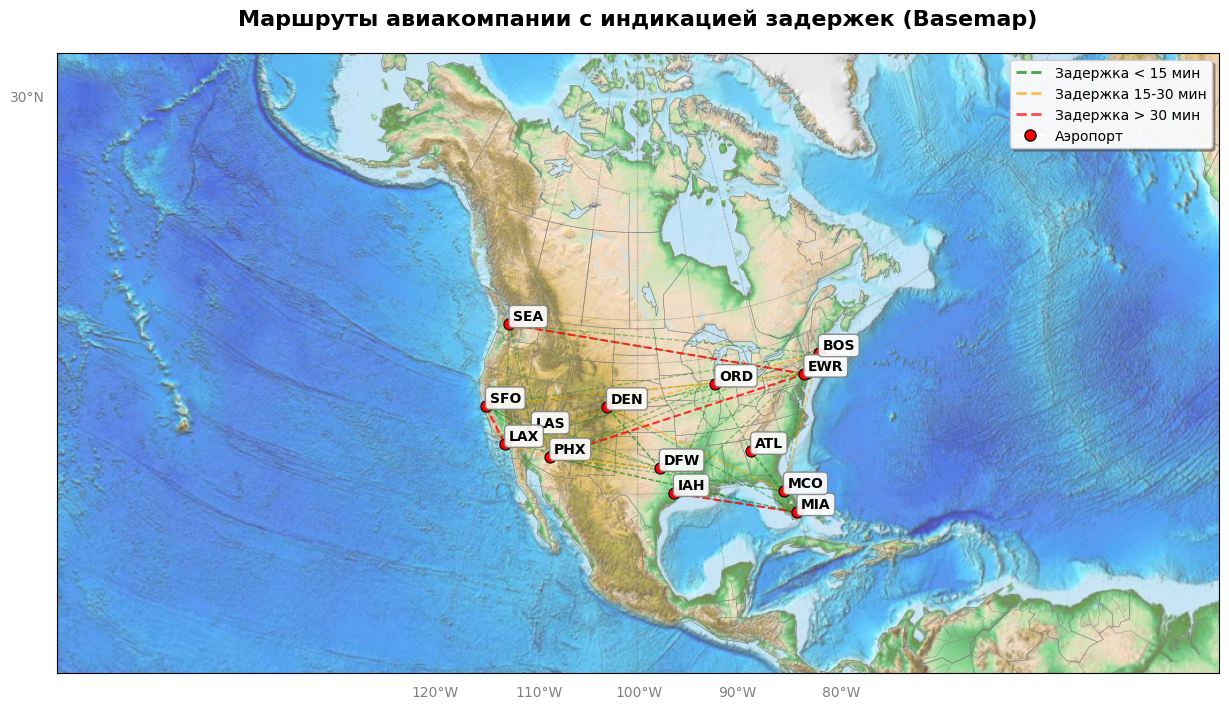


[8.1] 10 аэропортов по количеству вылетов:
   JFK: 347 рейсов
   DFW: 336 рейсов
   LAX: 334 рейсов
   MCO: 331 рейсов
   BOS: 328 рейсов
   ATL: 328 рейсов
   ORD: 317 рейсов
   SEA: 312 рейсов
   PHX: 311 рейсов
   SFO: 311 рейсов

[8.2] Средняя задержка по дням недели:
   Пн: 9.62 мин
   Вт: 11.37 мин
   Ср: 9.78 мин
   Чт: 9.28 мин
   Пт: 9.59 мин
   Сб: 10.14 мин
   Вс: 8.99 мин


In [ ]:
!pip install matplotlib pandas numpy basemap basemap-data-hires

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from matplotlib.lines import Line2D

%matplotlib inline
np.random.seed(42)

n_rows = 5000
airlines = ['AA', 'DL', 'UA', 'WN', 'AS', 'B6', 'F9', 'NK']

airport_coords = {
    'ATL': (-84.4281, 33.6367),
    'LAX': (-118.4085, 33.9416),
    'ORD': (-87.9048, 41.9786),
    'DFW': (-97.0380, 32.8968),
    'DEN': (-104.6732, 39.8617),
    'JFK': (-73.7781, 40.6413),
    'SFO': (-122.3750, 37.6189),
    'SEA': (-122.3081, 47.4502),
    'LAS': (-115.1523, 36.0800),
    'MCO': (-81.3081, 28.4294),
    'MIA': (-80.2906, 25.7932),
    'BOS': (-71.0052, 42.3656),
    'PHX': (-112.0114, 33.4373),
    'IAH': (-95.3414, 29.9844),
    'EWR': (-74.1687, 40.6895),
}
airports = list(airport_coords.keys())

data = {
    'YEAR': 2015,
    'MONTH': np.random.choice(range(1, 13), n_rows),
    'DAY': np.random.choice(range(1, 29), n_rows),
    'DAY_OF_WEEK': np.random.choice(range(1, 8), n_rows),
    'AIRLINE': np.random.choice(airlines, n_rows),
    'FLIGHT_NUMBER': np.random.randint(1, 5000, n_rows),
    'ORIGIN_AIRPORT': np.random.choice(airports, n_rows),
    'DESTINATION_AIRPORT': np.random.choice(airports, n_rows),
    'DEPARTURE_DELAY': np.random.exponential(15, n_rows).astype(int) - 5,
    'ARRIVAL_DELAY': np.random.exponential(15, n_rows).astype(int) - 5,
    'DISTANCE': np.random.randint(100, 3000, n_rows),
}

df = pd.DataFrame(data)

mask = np.random.random(n_rows) < 0.05
df.loc[mask, 'DEPARTURE_DELAY'] = np.nan
df.loc[mask, 'ARRIVAL_DELAY'] = np.nan
rows_before = len(df)
df = df.dropna(subset=['DEPARTURE_DELAY', 'ARRIVAL_DELAY'])
rows_after = len(df)
print(f"   Было строк: {rows_before}, стало: {rows_after}")
print(f"   Удалено: {rows_before - rows_after}")

print(f"\n[3.2] Фильтрация аэропортов (apply(len) == 3):")
before_filter = len(df)
df = df.loc[(df['ORIGIN_AIRPORT'].apply(len) == 3) &
            (df['DESTINATION_AIRPORT'].apply(len) == 3)]
after_filter = len(df)
print(f"   Было: {before_filter}, стало: {after_filter}")
print(f"   Удалено строк с некорректными кодами: {before_filter - after_filter}")

print(f"\n[3.3] Создание колонки DATE (pd.to_datetime):")
df['DATE'] = pd.to_datetime(df[['YEAR', 'MONTH', 'DAY']])
print(f"   Колонка DATE успешно создана")

print(f"\n[3.4] Создание колонки с маршрутом:")
df['ROUTE'] = df['ORIGIN_AIRPORT'] + df['DESTINATION_AIRPORT']
print(f"   Колонка ROUTE успешно создана")

print("\n[4] Добавление геоданных для визуализации")

print(f"\n[4.1] Добавление координат аэропортов (map):")
df['ORIGIN_LON'] = df['ORIGIN_AIRPORT'].map(lambda x: airport_coords.get(x, (np.nan, np.nan))[0])
df['ORIGIN_LAT'] = df['ORIGIN_AIRPORT'].map(lambda x: airport_coords.get(x, (np.nan, np.nan))[1])
df['DEST_LON'] = df['DESTINATION_AIRPORT'].map(lambda x: airport_coords.get(x, (np.nan, np.nan))[0])
df['DEST_LAT'] = df['DESTINATION_AIRPORT'].map(lambda x: airport_coords.get(x, (np.nan, np.nan))[1])

df = df.dropna(subset=['ORIGIN_LON', 'ORIGIN_LAT', 'DEST_LON', 'DEST_LAT'])
print(f"   Строк после добавления координат: {len(df)}")

print("\n[5] Анализ данных")

print("\n[5.1] Анализ по авиакомпаниям:")

airline_counts = df['AIRLINE'].value_counts()
print("\n   Количество рейсов по авиакомпаниям (value_counts):")
for airline, count in airline_counts.head(8).items():
    print(f"      {airline}: {count} рейсов ({count/len(df)*100:.1f}%)")

print("\n   Уникальные маршруты по авиакомпаниям (groupby + nunique):")
route_counts = df.groupby('AIRLINE')['ROUTE'].nunique().sort_values(ascending=False)
for airline, count in route_counts.head(8).items():
    print(f"      {airline}: {count} маршрутов")

print("\n[5.2] Фильтрация данных (loc):")
df_filtered = df.loc[df['DATE'] <= pd.to_datetime('2015-02-14')]
print(f"   Рейсов до 2015-02-14: {len(df_filtered)}")
print(f"   Это {len(df_filtered)/len(df)*100:.1f}% от всех данных")

print("\n[5.3] Статистика по задержкам (loc + mean, std, median):")
mean_delay = df.loc[df['DEPARTURE_DELAY'] > 0, 'DEPARTURE_DELAY'].mean()
std_delay = df.loc[df['DEPARTURE_DELAY'] > 0, 'DEPARTURE_DELAY'].std()
median_delay = df.loc[df['DEPARTURE_DELAY'] > 0, 'DEPARTURE_DELAY'].median()
print(f"   Средняя положительная задержка: {mean_delay:.2f} мин")
print(f"   Стандартное отклонение: {std_delay:.2f} мин")
print(f"   Медианная задержка: {median_delay:.0f} мин")

print("\n[6] Визуализация данных (обычные графики)")

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
df['DEPARTURE_DELAY'].hist(bins=30, color='steelblue', edgecolor='black')
plt.title('Распределение всех задержек вылета', fontsize=14)
plt.xlabel('Задержка (минуты)')
plt.ylabel('Количество рейсов')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
positive_delays = df[df['DEPARTURE_DELAY'] > 0]['DEPARTURE_DELAY']
positive_delays.hist(bins=20, color='coral', edgecolor='black', range=(0, 100))
plt.title('Распределение положительных задержек', fontsize=14)
plt.xlabel('Задержка (минуты)')
plt.ylabel('Количество рейсов')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
airline_counts.head(10).plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Топ-10 авиакомпаний по количеству рейсов', fontsize=14)
plt.xlabel('Авиакомпания')
plt.ylabel('Количество рейсов')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

print("\n[7.1] Карта маршрутов авиакомпании с индикацией задержек:")

df_aa = df[df['AIRLINE'] == 'AA'].copy()
if len(df_aa) > 50:
    df_plot = df_aa.sample(n=50, random_state=42)
else:
    df_plot = df_aa.copy()

print(f"   Отображение маршрутов авиакомпании : {len(df_plot)}")

fig = plt.figure(figsize=(15, 10))
m = Basemap(projection='lcc', resolution='c',
            width=15E6, height=8E6,
            lat_0=45, lon_0=-100)

m.etopo(scale=0.5, alpha=0.7)

m.drawcoastlines(linewidth=0.5, color='gray')
m.drawcountries(linewidth=0.5, color='gray')
m.drawstates(linewidth=0.3, color='gray')

parallels = np.arange(30, 51, 5)
meridians = np.arange(-120, -70, 10)
m.drawparallels(parallels, labels=[1,0,0,0], fontsize=10, color='gray', alpha=0.5, linewidth=0.5)
m.drawmeridians(meridians, labels=[0,0,0,1], fontsize=10, color='gray', alpha=0.5, linewidth=0.5)

orig_xy = []
dest_xy = []
colors = []
alphas = []
linewidths = []

for idx, row in df_plot.iterrows():
    x1, y1 = m(row['ORIGIN_LON'], row['ORIGIN_LAT'])
    x2, y2 = m(row['DEST_LON'], row['DEST_LAT'])
    orig_xy.append((x1, y1))
    dest_xy.append((x2, y2))

    delay = row['DEPARTURE_DELAY']
    if delay > 30:
        colors.append('red')
        alphas.append(0.8)
        linewidths.append(1.5)
    elif delay > 15:
        colors.append('orange')
        alphas.append(0.6)
        linewidths.append(1.2)
    else:
        colors.append('green')
        alphas.append(0.4)
        linewidths.append(1.0)

for i in range(len(orig_xy)):
    plt.plot([orig_xy[i][0], dest_xy[i][0]],
             [orig_xy[i][1], dest_xy[i][1]],
             color=colors[i], alpha=alphas[i], lw=linewidths[i],
             linestyle='--')

print(f"   Нарисовано маршрутов: {len(orig_xy)}")

airports_in_plot = set(df_plot['ORIGIN_AIRPORT'].tolist() +
                       df_plot['DESTINATION_AIRPORT'].tolist())

for airport in airports_in_plot:
    lon, lat = airport_coords.get(airport, (None, None))
    if lon is not None and lat is not None:
        x, y = m(lon, lat)
        plt.plot(x, y, 'ro', markersize=8,
                markeredgecolor='black', markeredgewidth=0.8, zorder=5)
        plt.text(x+50000, y+50000, airport, fontsize=10, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white',
                         alpha=0.9, edgecolor='gray'), zorder=6)

legend_elements = [
    Line2D([0], [0], color='green', alpha=0.7, linewidth=2, linestyle='--',
           label='Задержка < 15 мин'),
    Line2D([0], [0], color='orange', alpha=0.7, linewidth=2, linestyle='--',
           label='Задержка 15-30 мин'),
    Line2D([0], [0], color='red', alpha=0.7, linewidth=2, linestyle='--',
           label='Задержка > 30 мин'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=8,
           markeredgecolor='black', label='Аэропорт')
]

plt.legend(handles=legend_elements, loc='upper right', fontsize=10,
          framealpha=0.95, fancybox=True, shadow=True)

plt.title('Маршруты авиакомпании с индикацией задержек (Basemap)',
          fontsize=16, pad=20, weight='bold')
plt.show()


print("\n[8.1] 10 аэропортов по количеству вылетов:")
top_airports = df['ORIGIN_AIRPORT'].value_counts().head(10)
for airport, count in top_airports.items():
    print(f"   {airport}: {count} рейсов")

print("\n[8.2] Средняя задержка по дням недели:")
day_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
delay_by_day = df.groupby('DAY_OF_WEEK')['DEPARTURE_DELAY'].mean()
for day in range(1, 8):
    print(f"   {day_names[day-1]}: {delay_by_day[day]:.2f} мин")